# Arbitrary State Zero-Shot Skill Visualization

This notebook demonstrates how to use the `rollout_arbitrary_zero_shot` and `visualize_arbitrary_zero_shot` functions to test an agent's ability to reach an arbitrary goal state.

In [2]:
import matplotlib.pyplot as plt
import sys, os

sys.path.append("..")
os.environ["ROOT_DIR"] = ".."

from result_inspection.toy_maze import load_exp_data
from result_inspection.toy_maze_zero_shot import (
    rollout_arbitrary_zero_shot,
    visualize_arbitrary_zero_shot
)

# Set a larger default figure size for plots
plt.rcParams['figure.figsize'] = [10, 10]

## 1. Load Experiment Data

In [3]:
# Load the experiment data for the desired agent (e.g., edl_sr_smm)
exp_name = "square_maze/edl_sr_smm"
exp, cmap = load_exp_data(exp_name)

## 2. Run and Visualize Rollouts for a Single Goal

Here, we define an arbitrary start and goal position and test the agent's performance.

In [6]:
# Define an arbitrary start and goal position
# Ensure these are not inside a wall
start_pos = (4.0, -4.0)
goal_pos = (2.0, 0.0)

# First, generate the trajectory logs for this experiment
log_dir = rollout_arbitrary_zero_shot(
    exp,
    start_pos=start_pos,
    goal_pos=goal_pos,
    num_rollouts=10, # Generate 10 trajectories
    start_pos_random_range=0.3
)

Saving arbitrary zero-shot trajectories to: arbitrary_zero_shot_logs/square_maze/edl_sr_smm/s_4.0_-4.0_g_2.0_0.0
Arbitrary zero-shot rollouts completed and saved.


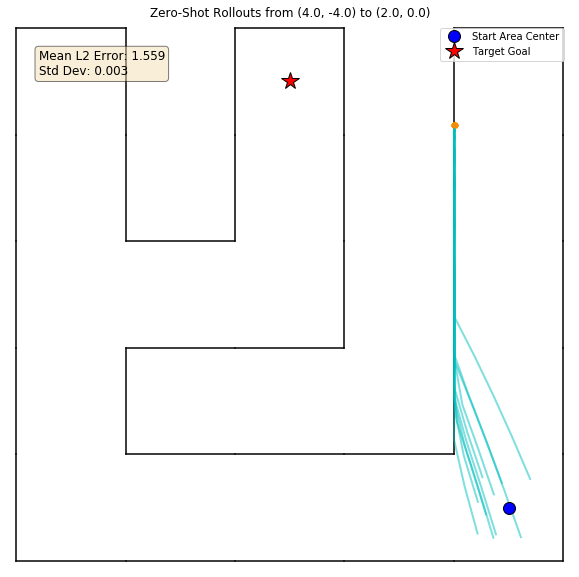

In [7]:
# Now, visualize the results from the generated logs
if log_dir:
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    visualize_arbitrary_zero_shot(
        exp,
        log_dir=log_dir,
        start_pos=start_pos,
        goal_pos=goal_pos,
        ax=ax
    )
    plt.show()